In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [10]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    plot_ball_behavior,
    plot_all_trajectories,
    plot
)
from scipy import ndimage
from skimage.feature import graycomatrix, graycoprops
from scipy.fft import fft2, fftshift
import cv2
from src.classify import classify_trajectories

In [3]:
model = "bruss"
ds_id = "param_sweep"
ds, output_dir = get_dataset(model, ds_id)
df = ds.df
df = expand_json_column(df, "original_point", "op", True)
df = expand_json_column(df, "initial_condition", "ic", True)
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [4]:
df_sub = df[(df.ratio_b_a.between(1.5,2.0)) & (df.Du > 2)][:10]

102


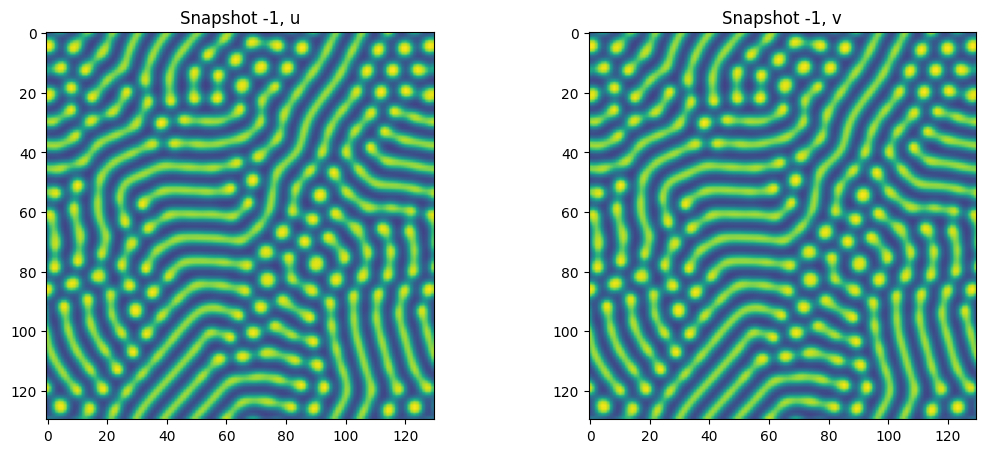

104


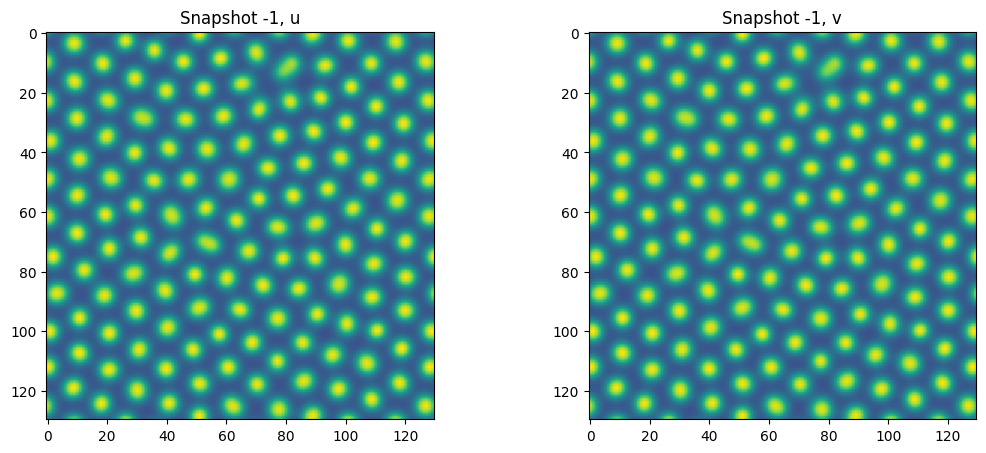

759


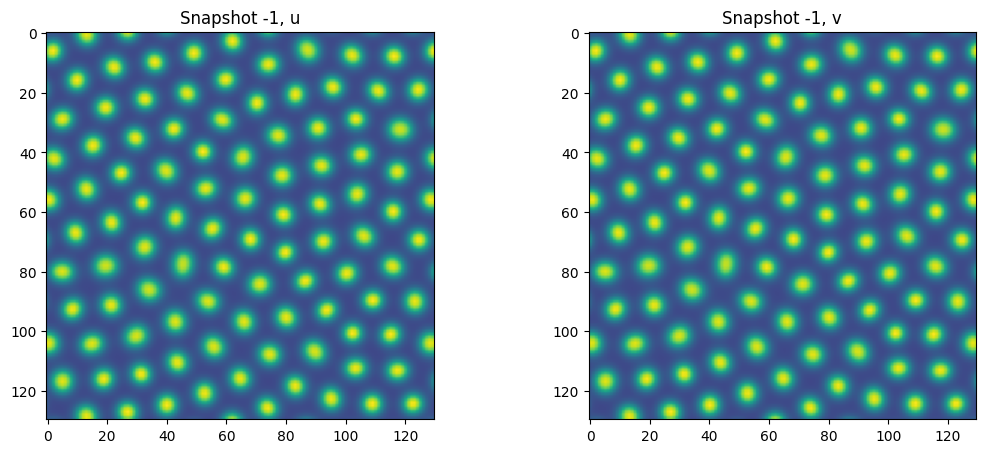

1104


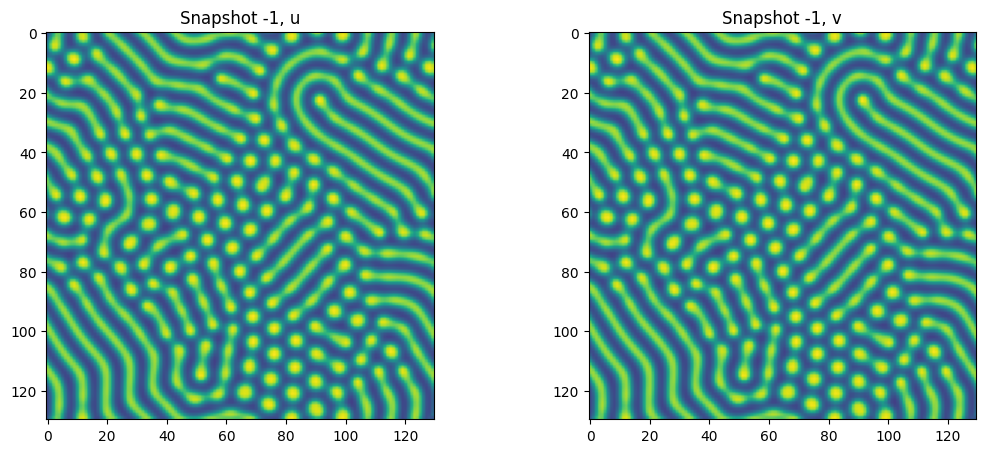

1169


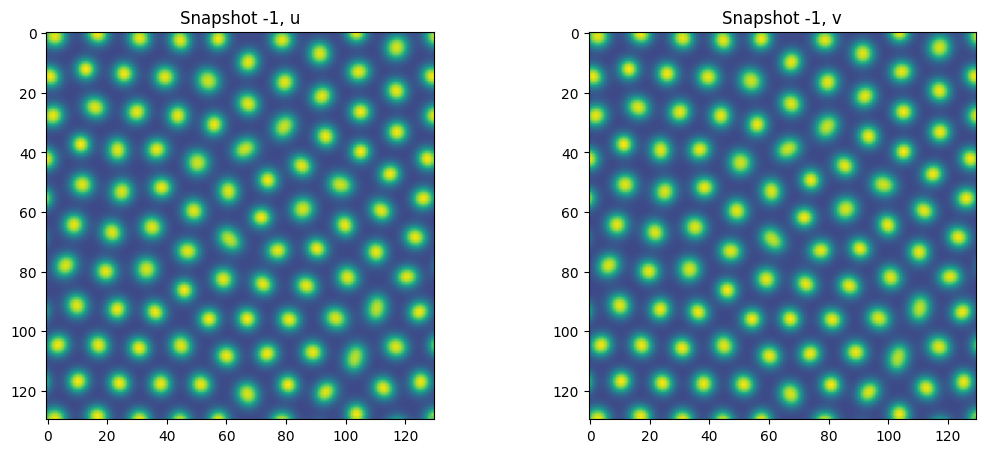

1294


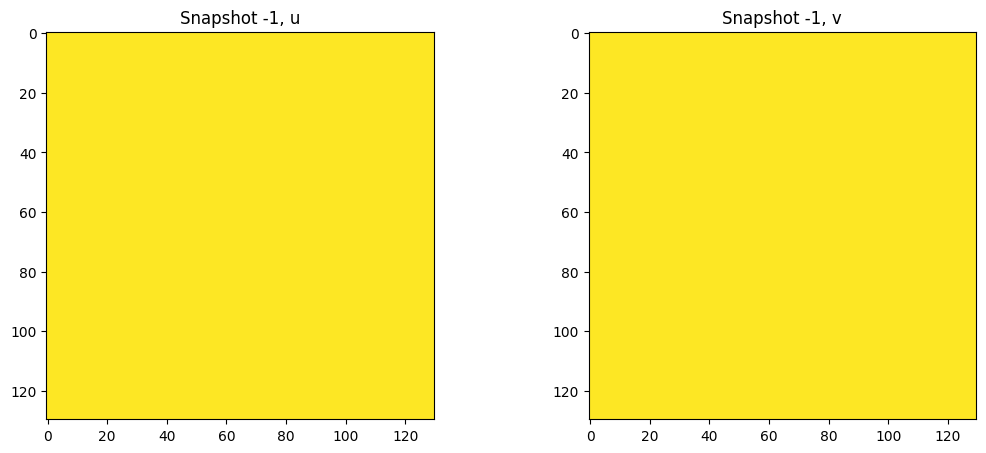

1307


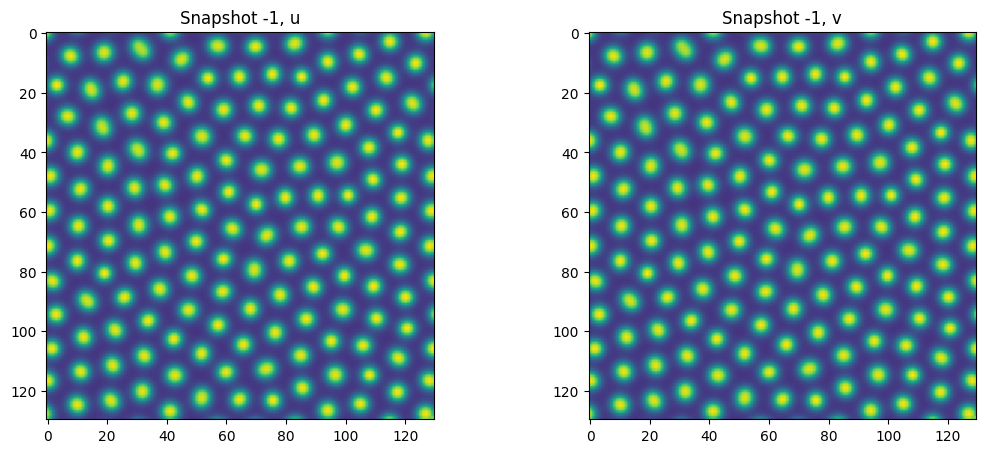

1465


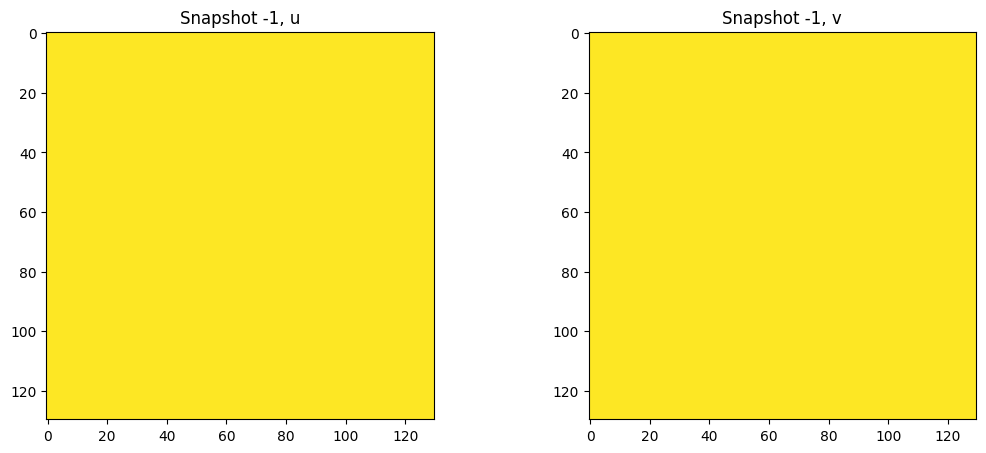

1627


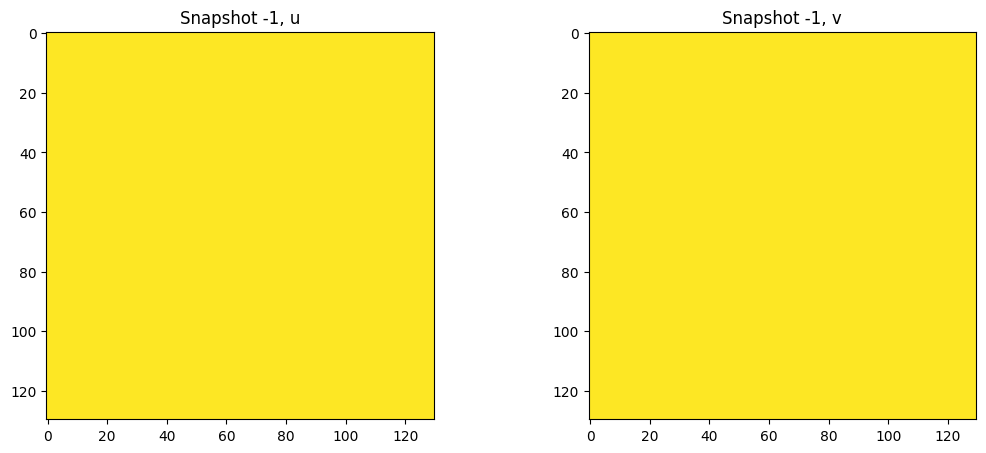

1690


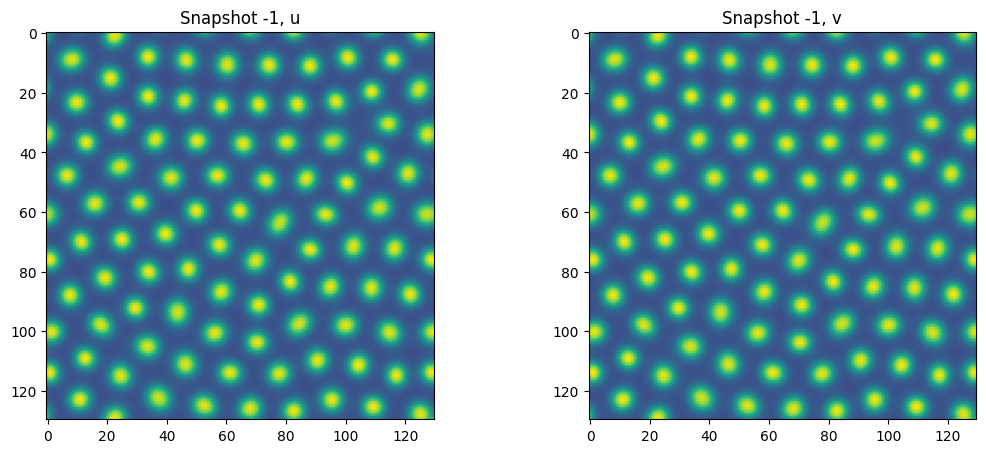

In [9]:
for i, row in df_sub.iterrows():
    d = ds.get_data(i)
    print(i, flush=True)
    fig, _, _ = plot(d, 0, np.max(d))
    plt.show()

yes 1104, 102
not 1690, 104

In [27]:
df_mini = df.iloc[[1104, 102, 1690, 104, 20, 219]]
df_mini["max_dt"]

1104     714.272095
102      900.905396
1690     395.801666
104      352.338531
20      1041.834106
219     1639.014893
Name: max_dt, dtype: float64

In [16]:
df_mini

,run_id,model,A,B,Du,Dv,Nx,dx,Nt,dt,...,op_A,op_B,op_Du,op_Dv,ic,ic_sigma_u,ic_sigma_v,category,ratio_b_a,ratio_d
1104,88c9fd58-ea04-4ffd-beb3-edd8721ebd4e,bruss,2.961007,5.343544,2.096775,14.667052,128,1.0,60000,0.0025,...,2.883424,5.369873,2.173531,14.513904,"{'sigma_u': 0.2, 'sigma_v': 0.2}",0.2,0.2,INT,1.804637,6.995053
102,1b32997d-6e86-47db-9094-0427c0558eb7,bruss,2.961007,5.343544,2.096775,14.667052,128,1.0,60000,0.0025,...,2.883424,5.369873,2.173531,14.513904,"{'sigma_u': 0.1, 'sigma_v': 0.1}",0.1,0.1,INT,1.804637,6.995053
1690,e9a909cf-a784-466a-89ce-ebd0432b123f,bruss,1.222538,2.399755,2.253919,13.905107,128,1.0,60000,0.0025,...,1.249041,2.510118,2.173531,14.513904,"{'sigma_u': 0.2, 'sigma_v': 0.2}",0.2,0.2,INT,1.962928,6.169302
104,ea258fc0-afee-42a6-b18c-5f8c2fa9d9f6,bruss,1.660068,2.975627,2.166682,14.312636,128,1.0,60000,0.0025,...,1.583921,3.000568,2.173531,14.513904,"{'sigma_u': 0.1, 'sigma_v': 0.1}",0.1,0.1,INT,1.792473,6.605785


In [19]:

def analyze_pattern(matrix):
    """
    Analyze a pattern in a float matrix and extract features to classify it.
    
    Parameters:
    -----------
    matrix : numpy.ndarray
        The input float matrix to analyze
        
    Returns:
    --------
    dict
        Dictionary containing the extracted features and classification
    """
    results = {}
    
    # Work with a copy of the matrix
    data = matrix.copy()
    
    # Normalize data to [0, 1] range for consistent analysis
    if data.max() != data.min():  # Avoid division by zero
        data = (data - data.min()) / (data.max() - data.min())
    
    # For GLCM analysis, we need uint8 (0-255)
    # But keep the original float data for other analyses
    gray_uint8 = (data * 255).astype(np.uint8)
    
    # 1. Basic statistical measures
    results['mean'] = np.mean(data)
    results['std'] = np.std(data)
    results['skewness'] = np.mean(((data - results['mean'])/results['std'])**3) if results['std'] > 0 else 0
    
    # 2. Fourier Transform Analysis
    f_transform = fftshift(np.abs(fft2(data)))
    f_transform_log = np.log(1 + f_transform)
    
    # Get the power spectrum
    power_spectrum = f_transform**2
    
    # Calculate radial profile (for isotropy analysis)
    h, w = data.shape
    center_y, center_x = h // 2, w // 2
    y, x = np.ogrid[-center_y:h-center_y, -center_x:w-center_x]
    r = np.sqrt(x*x + y*y)
    r_int = r.astype(int)
    
    # Create radial bins
    radial_bins = np.bincount(r_int.ravel(), weights=power_spectrum.ravel())
    norm_bins = np.bincount(r_int.ravel())
    radial_profile = radial_bins / (norm_bins + 1e-10)
    
    # 3. Directional analysis (for stripes)
    # Calculate directional variance in Fourier domain
    theta = np.arctan2(y, x)
    theta_bins = np.linspace(-np.pi, np.pi, 36)  # 10-degree bins
    directional_power = []
    
    for i in range(len(theta_bins)-1):
        mask = (theta >= theta_bins[i]) & (theta < theta_bins[i+1])
        directional_power.append(np.sum(power_spectrum[mask]))
    
    # Normalize
    directional_power = np.array(directional_power) / (np.sum(directional_power) + 1e-10)
    
    # Calculate directional variance (high for stripes, low for spots)
    results['directional_variance'] = np.var(directional_power)
    
    # 4. Texture analysis using GLCM
    glcm = graycomatrix(gray_uint8, distances=[1, 5, 10], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
                        levels=256, symmetric=True, normed=True)
    
    results['contrast'] = np.mean(graycoprops(glcm, 'contrast'))
    results['homogeneity'] = np.mean(graycoprops(glcm, 'homogeneity'))
    results['energy'] = np.mean(graycoprops(glcm, 'energy'))
    results['correlation'] = np.mean(graycoprops(glcm, 'correlation'))
    
    # 5. Connected component analysis using threshold-based approach
    # Generate binary image from the normalized data
    threshold = np.mean(data)  # Can be adjusted based on data distribution
    binary = (data > threshold).astype(np.uint8)
    
    # Label connected components
    labeled, num_components = ndimage.label(binary)
    
    # Calculate properties for each component
    component_stats = []
    for label_id in range(1, num_components + 1):
        component = (labeled == label_id)
        
        # Get component properties
        area = np.sum(component)
        
        # Calculate perimeter using gradient
        perimeter = np.sum(ndimage.sobel(component, 0) != 0) + np.sum(ndimage.sobel(component, 1) != 0)
        
        # Calculate circularity: 4π*area/perimeter²
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
            component_stats.append((area, circularity))
    
    if component_stats:
        areas, circularities = zip(*component_stats)
        results['mean_component_area'] = np.mean(areas)
        results['mean_circularity'] = np.mean(circularities)
        results['std_circularity'] = np.std(circularities)
        results['component_count'] = len(component_stats)
    else:
        results['mean_component_area'] = 0
        results['mean_circularity'] = 0
        results['std_circularity'] = 0
        results['component_count'] = 0
    
    # 6. Spatial autocorrelation (useful for periodic patterns)
    # Calculate correlation with shifted versions of itself
    max_shift = min(20, min(data.shape) // 4)  # Look at shifts up to 1/4 of image size
    autocorr_values = []
    
    for shift in range(1, max_shift + 1):
        # Horizontal shift
        correlation_h = np.corrcoef(data[:, shift:].flatten(), data[:, :-shift].flatten())[0, 1]
        # Vertical shift
        correlation_v = np.corrcoef(data[shift:, :].flatten(), data[:-shift, :].flatten())[0, 1]
        autocorr_values.append((correlation_h + correlation_v) / 2)
    
    results['first_min_autocorr'] = np.argmin(autocorr_values) + 1 if len(autocorr_values) > 0 else 0
    results['autocorr_decay_rate'] = (autocorr_values[0] - autocorr_values[-1]) / len(autocorr_values) if len(autocorr_values) > 0 else 0
    
    # 7. Wavelet-like analysis: Find dominant frequencies in rows and columns
    row_fft = np.abs(np.fft.fft(data, axis=1))
    col_fft = np.abs(np.fft.fft(data, axis=0))
    
    # Calculate average frequency peaks across rows and columns
    row_peak_freqs = []
    col_peak_freqs = []
    
    for row in row_fft:
        peaks = np.where((row[1:-1] > row[:-2]) & (row[1:-1] > row[2:]))[0] + 1
        if len(peaks) > 0:
            row_peak_freqs.extend(peaks)
    
    for col in col_fft:
        peaks = np.where((col[1:-1] > col[:-2]) & (col[1:-1] > col[2:]))[0] + 1
        if len(peaks) > 0:
            col_peak_freqs.extend(peaks)
    
    results['row_freq_std'] = np.std(row_peak_freqs) if row_peak_freqs else 0
    results['col_freq_std'] = np.std(col_peak_freqs) if col_peak_freqs else 0
    
    # Classification
    # Multiple criteria for robustness
    pattern_score = 0
    
    # Directional variance (main criterion)
    if results['directional_variance'] < 0.0005:
        pattern_score -= 1  # Favor spots
    else:
        pattern_score += 1  # Favor stripes
    
    # Circularity 
    if results.get('mean_circularity', 0) > 0.7:
        pattern_score -= 1  # Favor spots
    else:
        pattern_score += 1  # Favor stripes
        
    # Final classification
    if pattern_score < 0:
        results['pattern_type'] = 'spots'
    else:
        results['pattern_type'] = 'stripes'
    
    return results

def visualize_analysis(matrix, results):
    """
    Visualize the analysis results alongside the original matrix data.
    
    Parameters:
    -----------
    matrix : numpy.ndarray
        The input matrix
    results : dict
        Dictionary containing the analysis results
    """
    # Create figure
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    
    # Original pattern
    im0 = axs[0, 0].imshow(matrix, cmap='viridis')
    axs[0, 0].set_title('Original Pattern')
    plt.colorbar(im0, ax=axs[0, 0])
    
    # Fourier transform
    f_transform = fftshift(np.abs(fft2(matrix)))
    f_transform_log = np.log(1 + f_transform)
    im1 = axs[0, 1].imshow(f_transform_log, cmap='viridis')
    axs[0, 1].set_title('Fourier Transform (Log Scale)')
    plt.colorbar(im1, ax=axs[0, 1])
    
    # Binary threshold visualization
    threshold = np.mean(matrix)
    binary = (matrix > threshold).astype(np.uint8)
    im2 = axs[1, 0].imshow(binary, cmap='gray')
    axs[1, 0].set_title(f'Binary Threshold (>{threshold:.3f})')
    plt.colorbar(im2, ax=axs[1, 0])
    
    # Results text
    axs[1, 1].axis('off')
    axs[1, 1].text(0.1, 0.95, f"Pattern Type: {results['pattern_type'].upper()}", fontsize=14, fontweight='bold')
    axs[1, 1].text(0.1, 0.9, f"Directional Variance: {results['directional_variance']:.6f}", fontsize=12)
    axs[1, 1].text(0.1, 0.85, f"Mean Circularity: {results.get('mean_circularity', 'N/A'):.4f}", fontsize=12)
    axs[1, 1].text(0.1, 0.8, f"Component Count: {results.get('component_count', 'N/A')}", fontsize=12)
    axs[1, 1].text(0.1, 0.75, f"Contrast: {results['contrast']:.4f}", fontsize=12)
    axs[1, 1].text(0.1, 0.7, f"Homogeneity: {results['homogeneity']:.4f}", fontsize=12)
    axs[1, 1].text(0.1, 0.65, f"Energy: {results['energy']:.4f}", fontsize=12)
    axs[1, 1].text(0.1, 0.6, f"Correlation: {results['correlation']:.4f}", fontsize=12)
    axs[1, 1].text(0.1, 0.55, f"First Min Autocorr: {results.get('first_min_autocorr', 'N/A')}", fontsize=12)
    axs[1, 1].text(0.1, 0.5, f"Row Freq Std: {results.get('row_freq_std', 'N/A'):.4f}", fontsize=12)
    axs[1, 1].text(0.1, 0.45, f"Col Freq Std: {results.get('col_freq_std', 'N/A'):.4f}", fontsize=12)
    
    plt.tight_layout()
    return fig

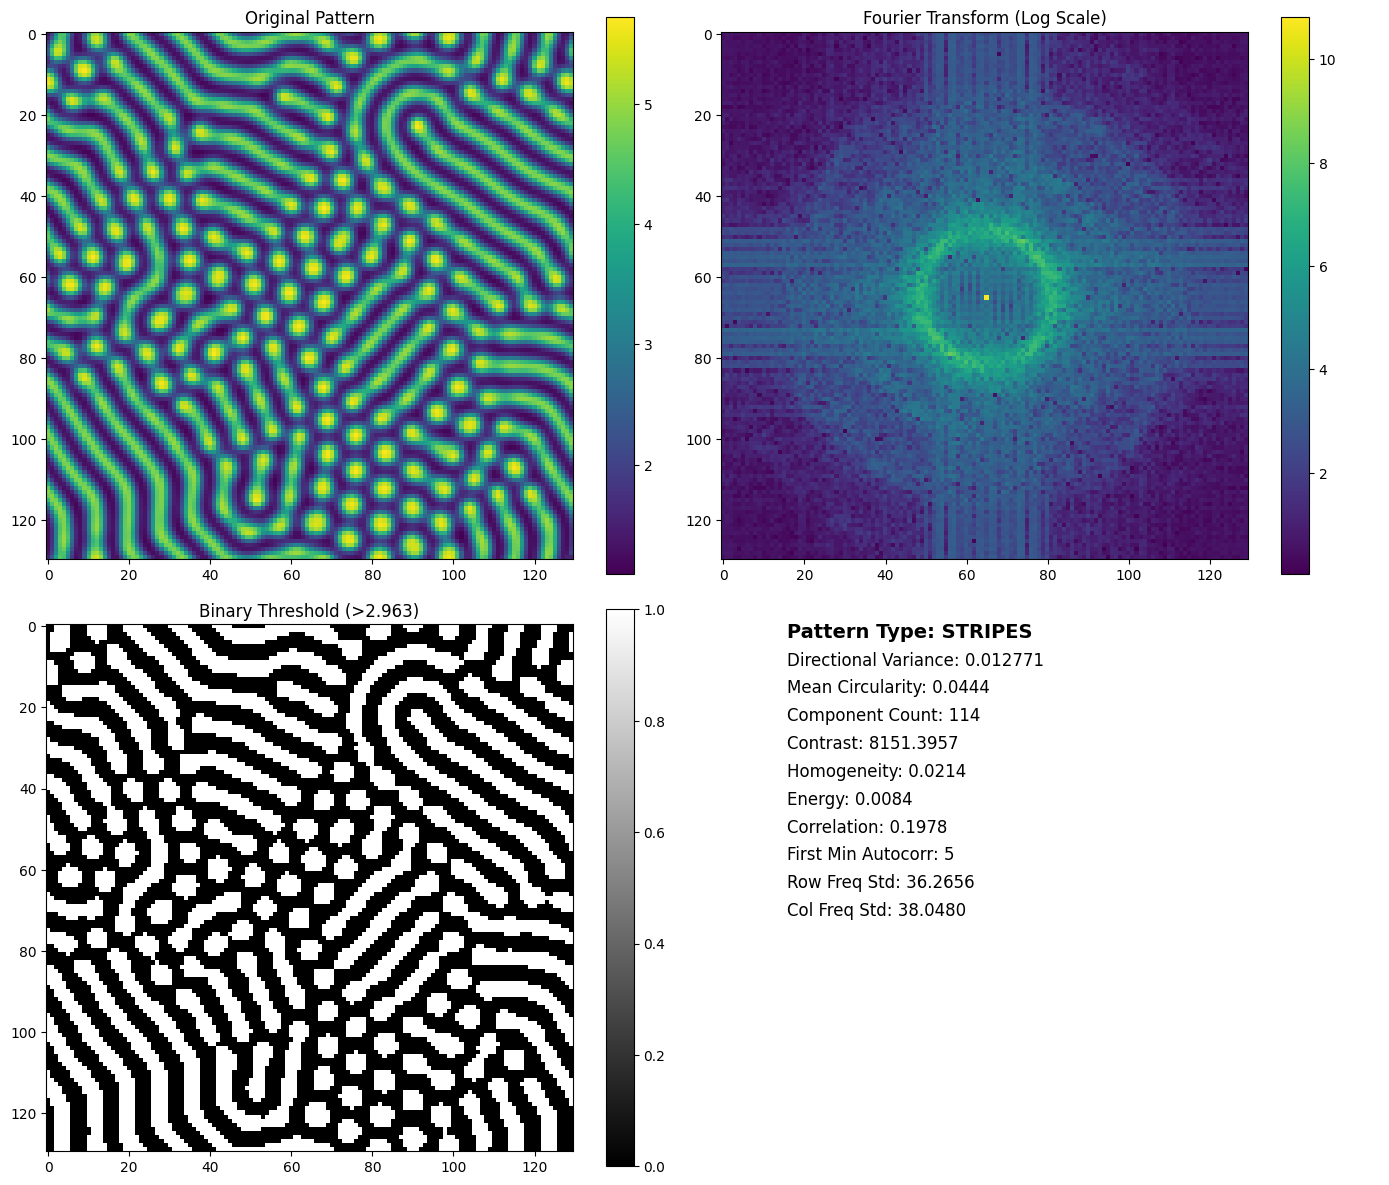

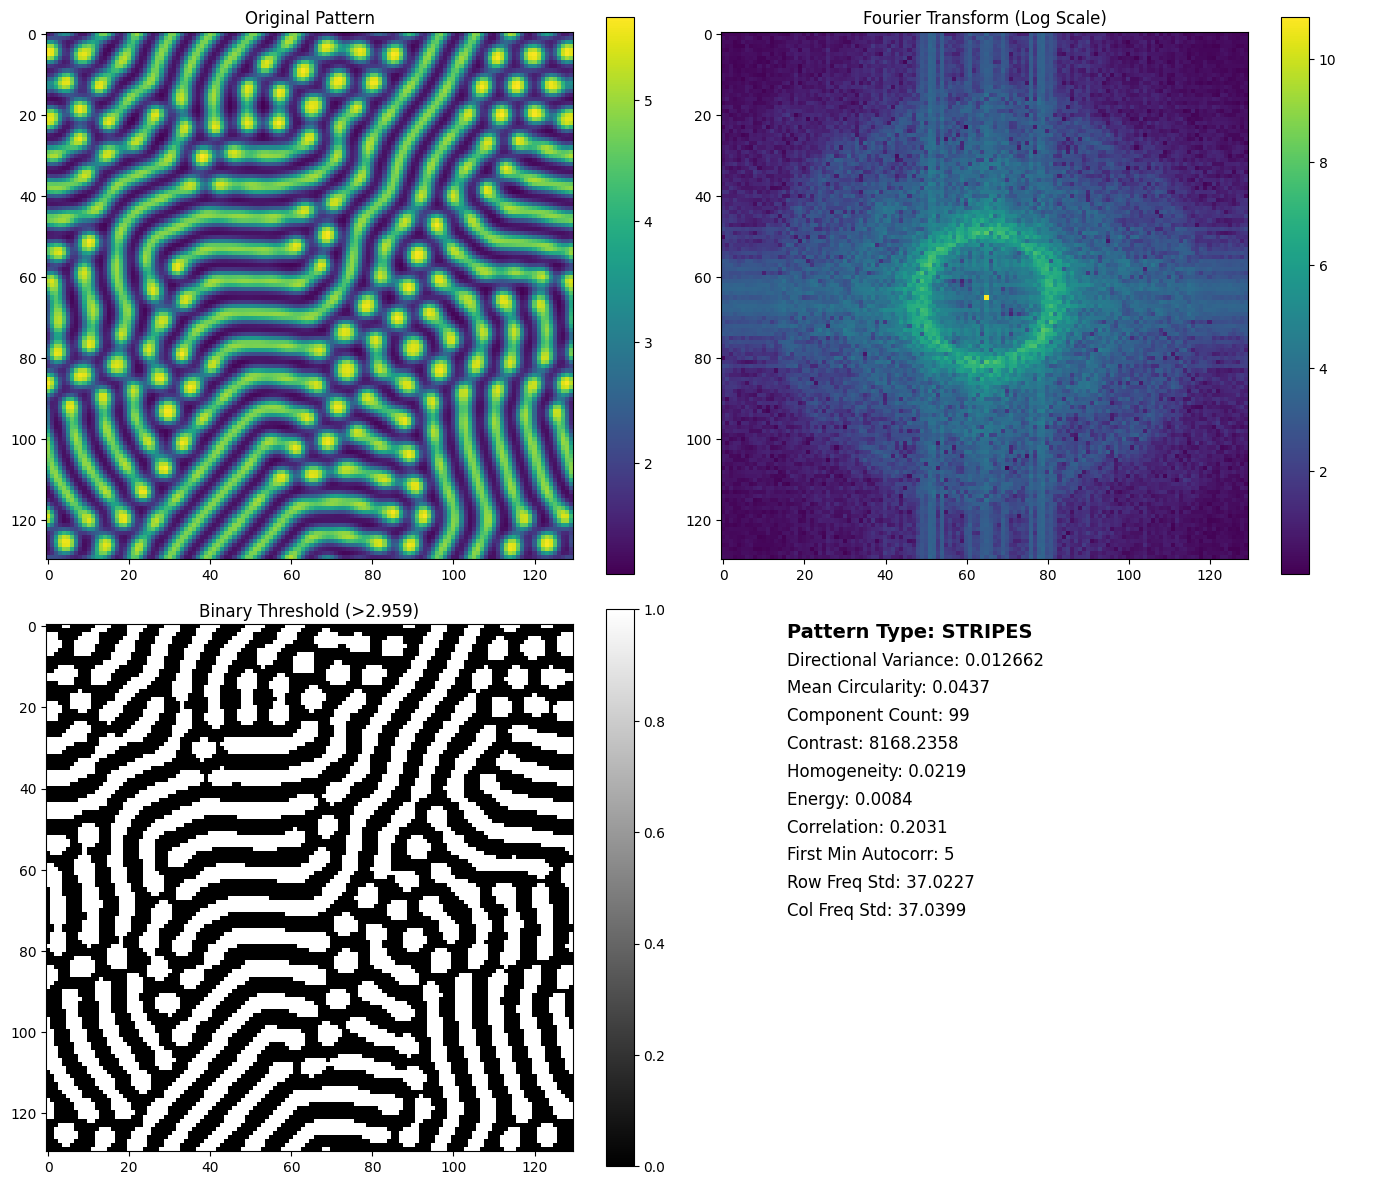

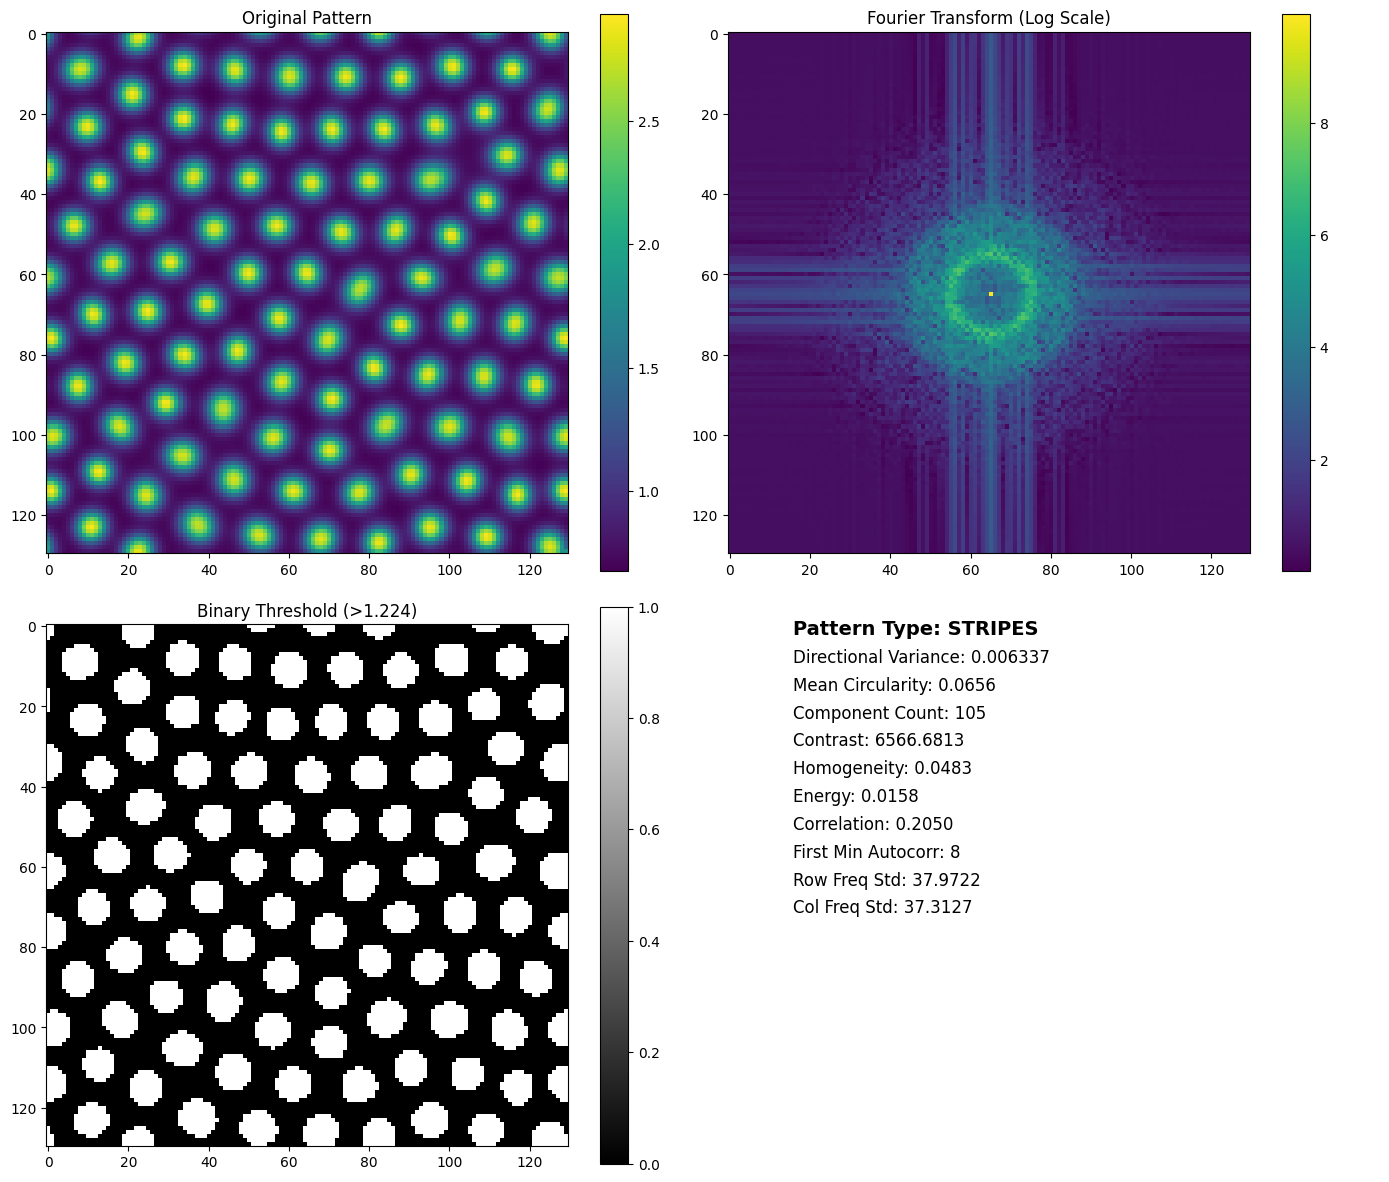

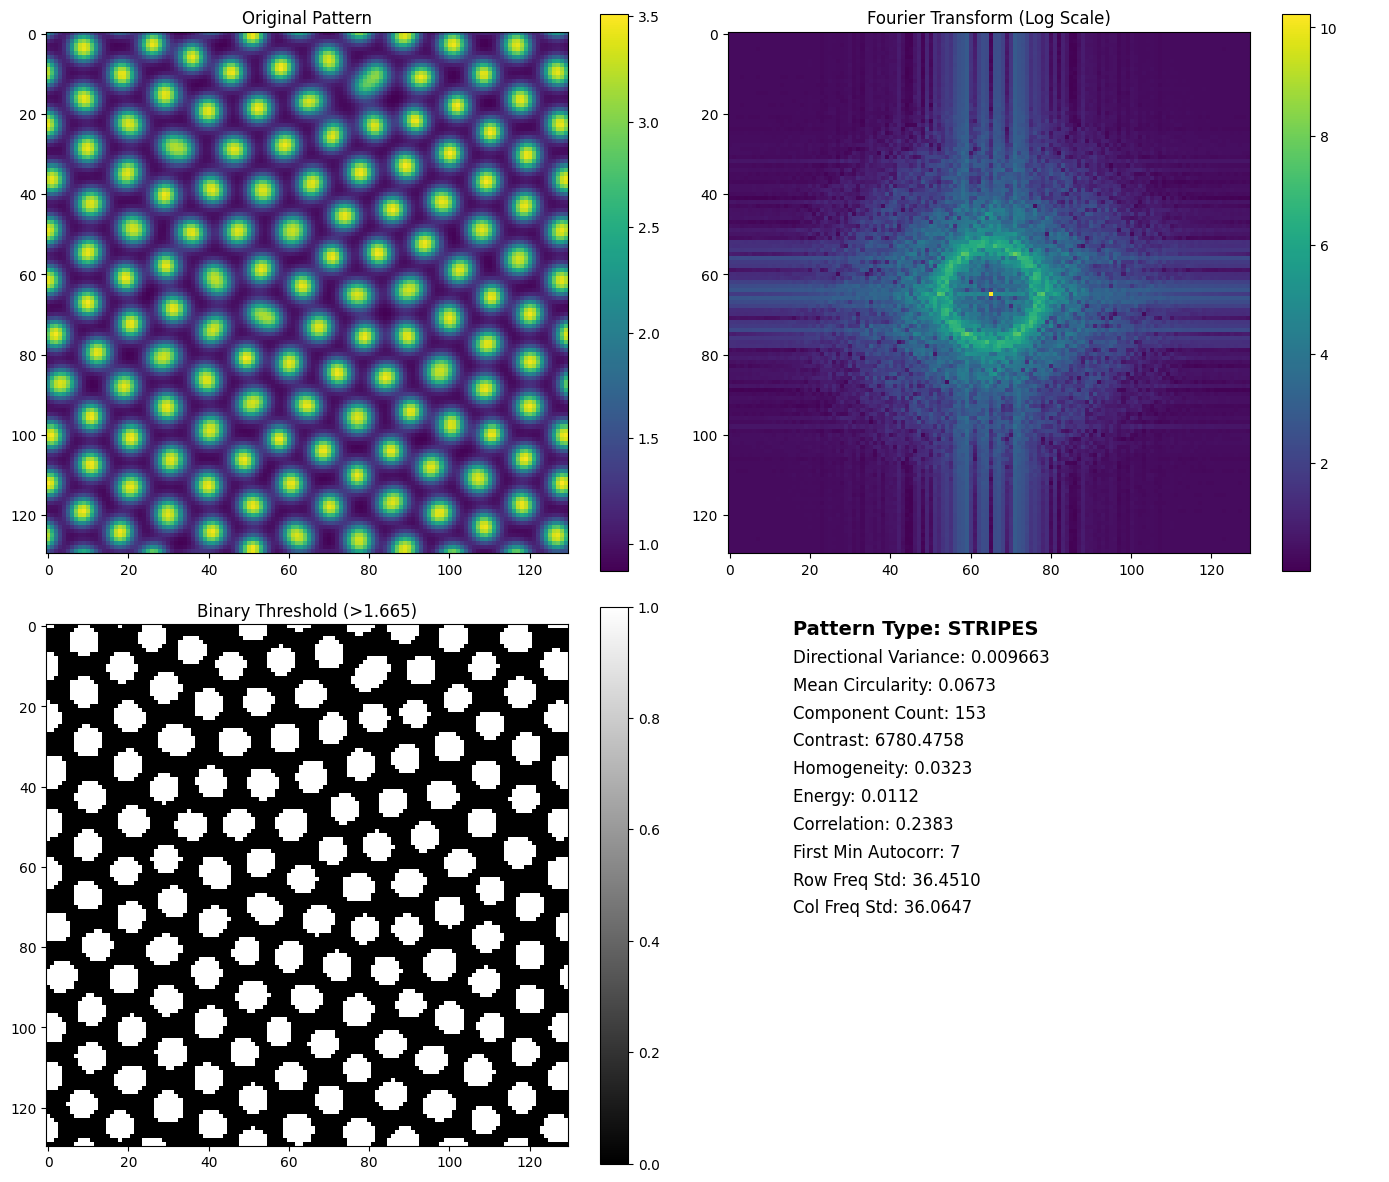

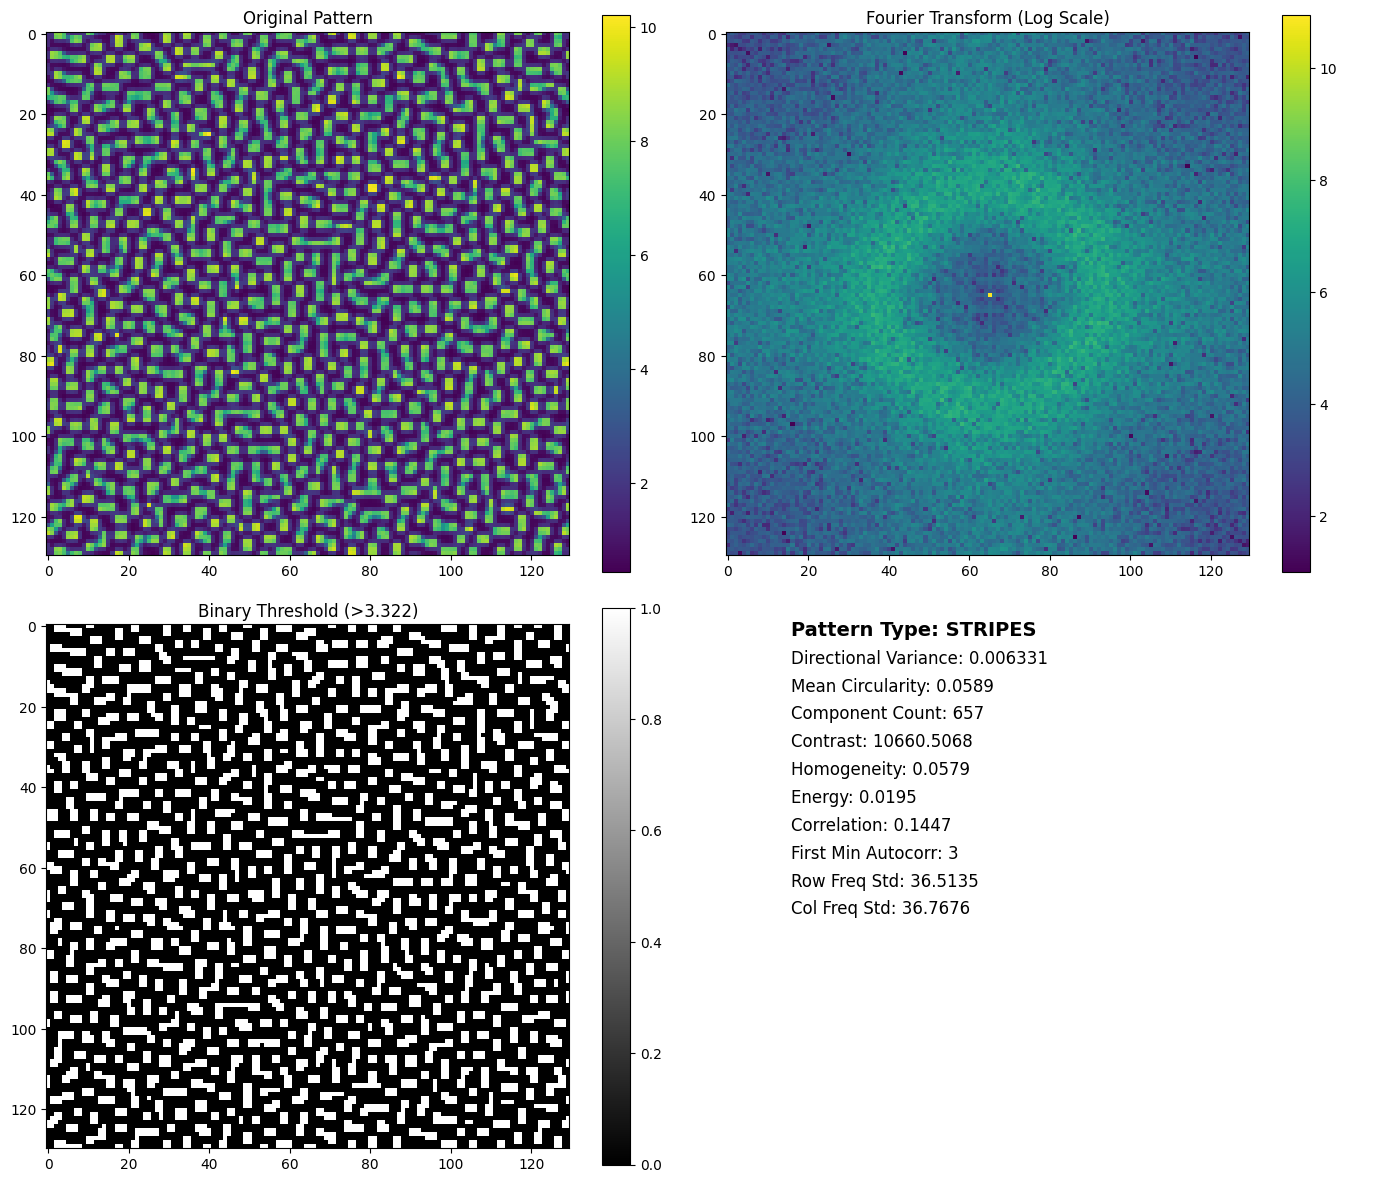

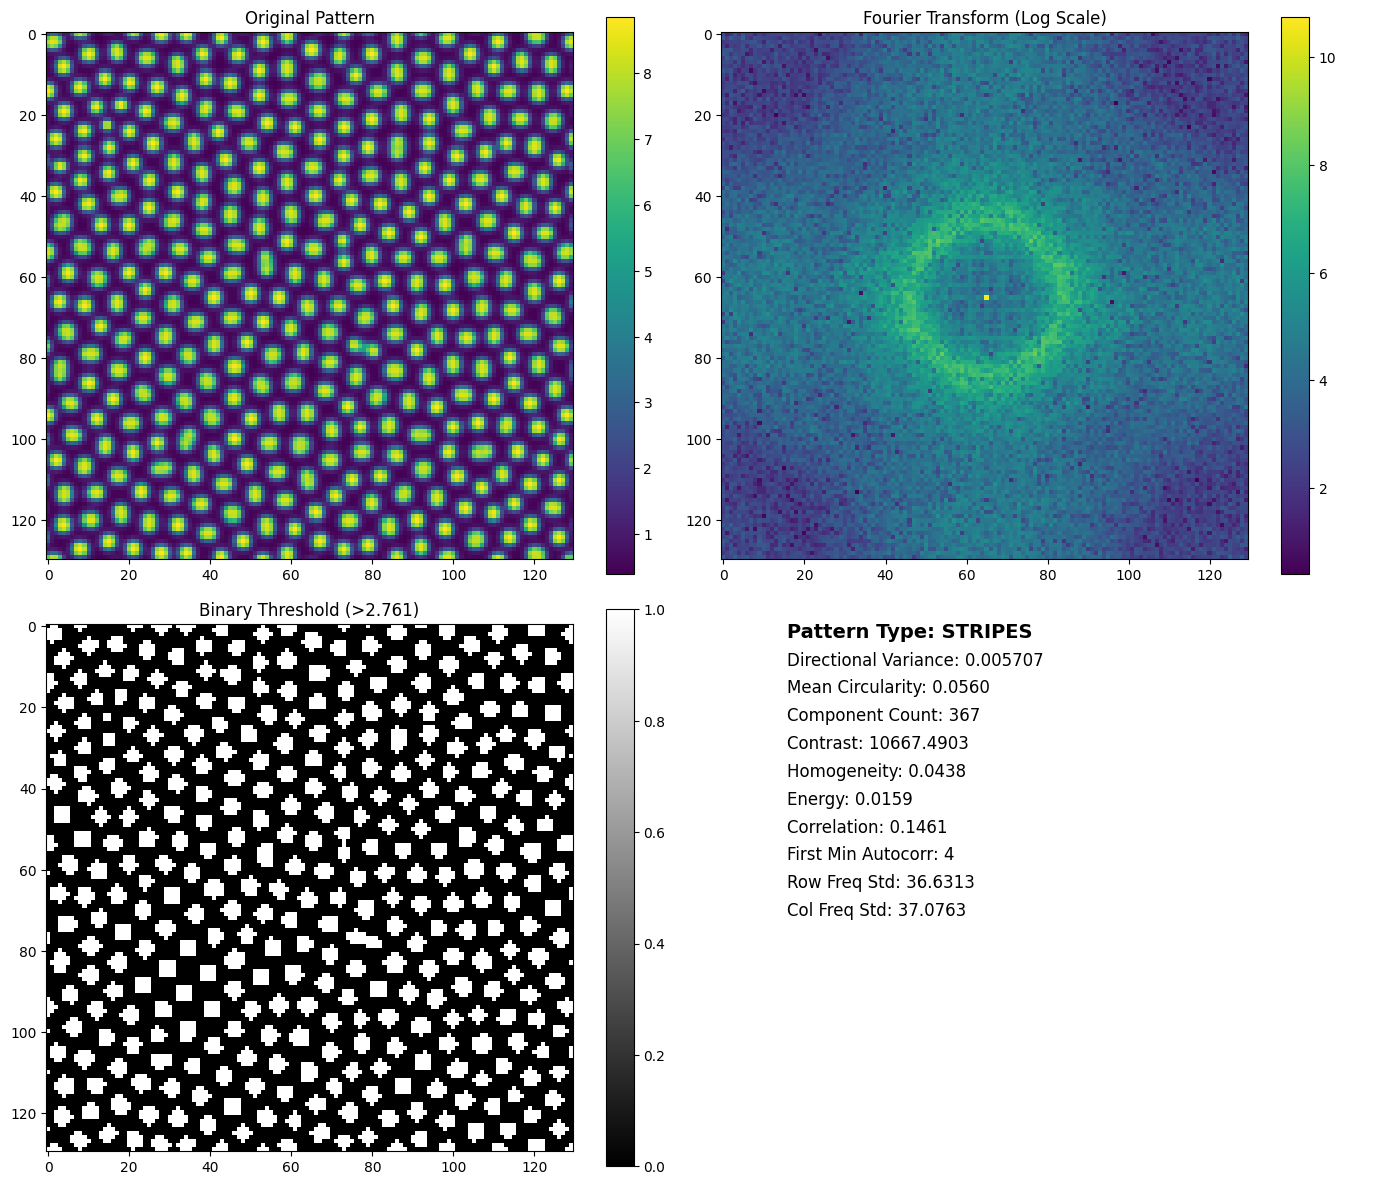

In [28]:
for i, row in df_mini.iterrows():
    d = ds.get_data(i)
    final_frame = d[-1, :, 0::2].astype(float)
    visualize_analysis(final_frame, analyze_pattern(final_frame))